<font size="5.8">--</font>  


Python functions and data files needed to run this notebook are available via this [link](https://github.com/MehdiRezvandehy/agentic_workflow_crewai_langchain.git).

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Using-MCP-to-Enhance-Agent-Capabilities" data-toc-modified-id="Using-MCP-to-Enhance-Agent-Capabilities-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Using MCP to Enhance Agent Capabilities</a></span></li><li><span><a href="#LangGraph-Specific-Setup" data-toc-modified-id="LangGraph-Specific-Setup-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>LangGraph-Specific Setup</a></span></li><li><span><a href="#Incorporating-MCP-into-the-architecture" data-toc-modified-id="Incorporating-MCP-into-the-architecture-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Incorporating MCP into the architecture</a></span></li><li><span><a href="#Local-MCP-Server" data-toc-modified-id="Local-MCP-Server-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Local MCP Server</a></span></li><li><span><a href="#Remote-MCP-Server" data-toc-modified-id="Remote-MCP-Server-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Remote MCP Server</a></span></li><li><span><a href="#Summary" data-toc-modified-id="Summary-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Summary</a></span><ul class="toc-item"><li><span><a href="#Risk-Using-MCP" data-toc-modified-id="Risk-Using-MCP-6.1"><span class="toc-item-num">6.1&nbsp;&nbsp;</span>Risk Using MCP</a></span></li></ul></li></ul></div>

# Using MCP to Enhance Agent Capabilities

**Model Context Protocol (MCP)** invented by **Antropic** in November 2024, it grows until 2025 around the concept of standardizing of the way we pass information to LLM. MCP is an open standard designed to bridge AI agents with the world of data and tools, to plug in many different sources of context as making tools is pretty ad-hoc so developers write custom code or use specialized plugins for each data source or API.

MCP is not itself, code, framework or LLM, it is a set of rules that we are would agree to provide a resource and creat a server that itself holds context for LLM. Broadly speaking, MCP is valuable when you want **an LLM to interact with external systems, either by accessing information beyond its training data or by taking actions on your behalf.**

* **Context** refers to external data the LLM can use, such as web search results, databases, or internal company information that was not included during training.
* **Tools** are executable functions the LLM can call to perform tasks, such as creating a pull request, sending an email, querying APIs, or updating files.
* **Protocol** refers to a standardized set of rules that defines how an LLM application communicates with external tools, data sources, and services.

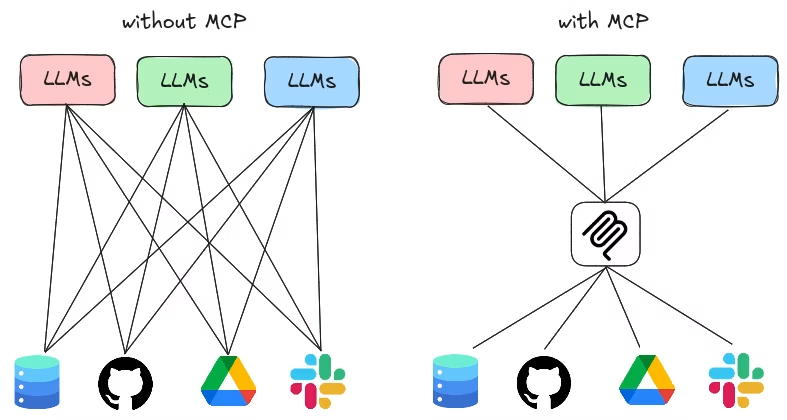
Source: https://hoangndst.com/blog/model-context-protocol

The image below compares AI architectures before and after the Model Context Protocol (MCP). Before MCP, LLMs needed separate custom integrations for every tool. With MCP, the LLM connects through a single unified interface, while MCP handles communication with external tools. This simplifies integration, improves scalability, and standardizes connectivity across AI systems.

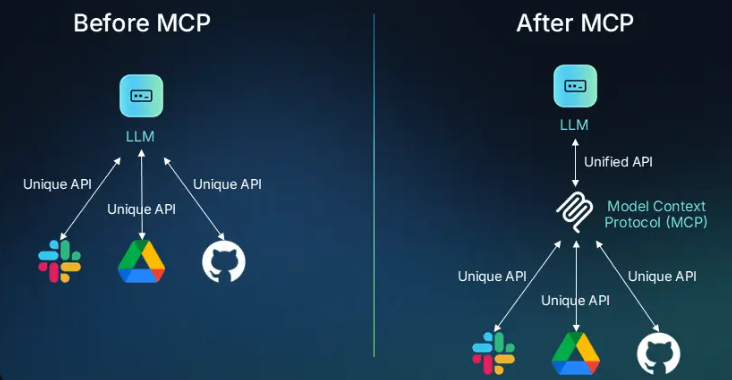
Source: https://mcpshowcase.com/blog/what-is-mcp

MCP provides three main components for LLMs: **Tools, Resources, and Prompts**. However, most attention is usually given to **Tools**, which define a standard way to build and share capabilities across systems.

A simple example: Person A builds an MCP server that exposes certain APIs as tools. They package it with required environment variables (like API keys) and open-source it. Now anyone—Person B, C, D, and others—can plug into this MCP server and instantly gain access to those tools without rebuilding the integration themselves: **MCP enables reusable, shareable tool access where one provider can expose capabilities and many consumers can easily use them.**

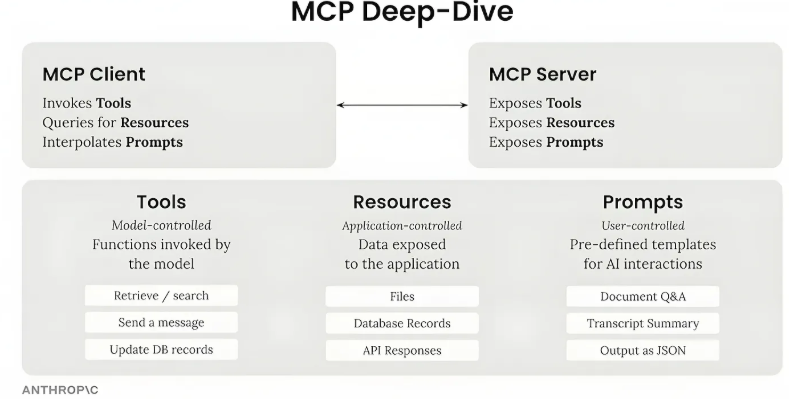
https://ppaolo.substack.com/p/how-anthropics-mcp-outshined-openais

The MCP is designed to solve the **M×N integration problem**, where connecting *M* AI models to *N* tools or data sources would otherwise require a large number of custom integrations. Without a common standard, developers must create and maintain separate connectors for each model–tool combination, leading to significant complexity and maintenance overhead. MCP introduces a **universal communication protocol** that acts as a common interface between AI applications and external systems. As a result, any MCP-compatible AI application—such as an IDE, chatbot, or agent platform—can interact with any MCP-compliant tool, database, or service without additional custom development. This standardization improves interoperability, reduces engineering effort, simplifies system integration, and enables AI ecosystems to scale more efficiently.

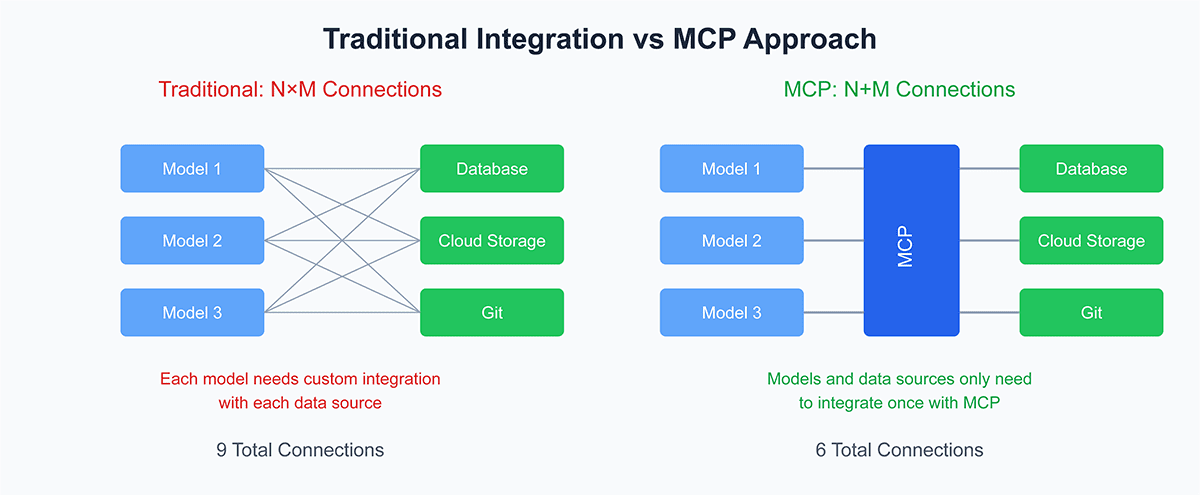
Source: https://humanloop.com/blog/mcp

Extending this idea, an **MCP server** is responsible for providing functionality by connecting to external tools and data sources, while an **MCP client** is what consumes and interacts with those capabilities through a user interface or application layer.

For example, we can use **Streamlit**, a lightweight Python framework for building interactive web apps, to quickly create an **MCP client** UI. This allows us to focus on connecting to remote MCP servers and exploring different AI capabilities, while Streamlit handles the interface with minimal setup and fast prototyping.

A working MCP server can be very simple. Here, the FastMCP server is essentially a FastAPI-based server designed specifically for MCP resources, prompts, and tools. 

The code below shows a simple end-to-end functional MCP example.

In [1]:
from mcp.server.fastmcp import FastMCP

mcp = FastMCP("MCP Simple Example")

@mcp.tool()
def add_numbers(a: int, b: int) -> int:
    return a + b

# Show registered tools
print(mcp._tool_manager.list_tools())

[Tool(fn=<function add_numbers at 0x0000020F6BE68E00>, name='add_numbers', title=None, description='', parameters={'properties': {'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}, 'required': ['a', 'b'], 'title': 'add_numbersArguments', 'type': 'object'}, fn_metadata=FuncMetadata(arg_model=<class 'mcp.server.fastmcp.utilities.func_metadata.add_numbersArguments'>, output_schema={'properties': {'result': {'title': 'Result', 'type': 'integer'}}, 'required': ['result'], 'title': 'add_numbersOutput', 'type': 'object'}, output_model=<class 'mcp.server.fastmcp.utilities.func_metadata.add_numbersOutput'>, wrap_output=True), is_async=False, context_kwarg=None, annotations=None, icons=None, meta=None)]


Companies are building MCP servers for their own platforms — Notion has one, Zapier has one, and there are also several third-party MCP servers for Salesforce. This shows that building MCP servers is not limited to the companies that own the systems; developers and the broader community can build them as well.

For example, Zapier MCP lets your AI agent connect to thousands of apps through a standardized MCP interface. Instead of building separate integrations for each service, the AI simply uses Zapier’s MCP layer to access tools like email, messaging, spreadsheets, and CRMs in a unified way.

Briefly, the workflow is:

1. **Create a Zapier MCP server**:
   Zapier exposes actions from apps like Gmail, Slack, Google Sheets, and Notion as MCP tools.

2. **Connect the MCP server to your AI agent**:
   Your LLM application (for example using LangChain, LangGraph, or a custom agent) connects to the Zapier MCP endpoint.

3. **The AI discovers available tools automatically**:
   The agent can see available actions such as:

   * Send email
   * Create calendar event
   * Update spreadsheet
   * Post Slack message

4. **The AI calls tools when needed**:
   Example:

   * User says: “Send meeting notes to the team.”
   * AI decides to use Gmail + Slack tools through Zapier MCP.
   * Zapier executes the actions securely.

**This removes the need to manually build separate API integrations for every app.**

# LangGraph-Specific Setup

To make this concrete, let’s walk through a simple example of running an MCP-style tool integration in LangGraph and see how an agent can be granted access to external tools in practice.

In [2]:
# A way to get a tool from langchain
from langchain_community.agent_toolkits.load_tools import load_tools
# Core LLM interface (OpenAI chat models)
from langchain_openai import ChatOpenAI
from rich.markdown import Markdown
import os
from dotenv import load_dotenv
load_dotenv(override=True)
    
# Read API key from environment variable
os.environ["SERPAPI_API_KEY"] = os.getenv("SERP_API_KEY")  # https://serpapi.com for a free token!
# LLM Model
os.environ['OPENAI_API_KEY'] = os.environ.get("OPENAI_API_KEY")
model = ChatOpenAI(model='gpt-4o-mini')

tools = load_tools(["serpapi"])

None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [3]:
tools[0].run('Mehdi Rezvandehy')

"['As a Principal Data Scientist, my expertise encompasses diverse areas such as Advanced Machine Learning, Predictive Modeling, Customer Analytics, and ...', 'University of Calgary - Integrating seismic attributes in the accurate modeling of geological structures and determining the storage of the gas reservoir in ...', 'Mehdi is a Principal Data Scientist at ATB Financial, leveraging machine learning and Generative AI to create cutting-edge solutions in the banking industry.', 'Ph.D Researcher at University of Alberta. Department of Civil and Environmental Engineering, School of Mining and Petroleum Engineering Edmonton, Canada ...', 'Expert in labor economics at lssi-Labour and Social Security Institute. Biomedical (Biomechanical) Engineer | Orthopedic 3D Printing & CAD | AI Agents & n8n ...', 'Integrating seismic attributes in the accurate modeling of geological structures and determining the storage of the gas reservoir in Gorgan Plain (North of Iran).', 'Mehdi Rezvandehy: 3 Follo

In [4]:
# Use MemorySaver to save short term memory agent
from langgraph.checkpoint.memory import MemorySaver

# Prebuilt ReAct-style agent + state injection utilities
from langgraph.prebuilt import InjectedState, create_react_agent

agent_executor = create_react_agent(model, 
                                    tools, 
                                    checkpointer=MemorySaver())

C:\Users\mrezv\AppData\Local\Temp\ipykernel_35548\4096780630.py:7: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_executor = create_react_agent(model,


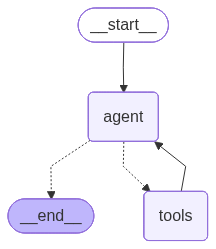

In [5]:
# Compile the graph
from IPython.display import Image, display

display(Image(agent_executor.get_graph().draw_mermaid_png()))

In [6]:
query = "Who is Mehdi Rezvandehy, where does he work and what is his background."

response = agent_executor.invoke({"messages": [{"role": "user","content": query}]},
    config={"configurable": {"thread_id": "demo"}})

[06/08/26 21:09:21] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=364648;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=538471;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1038\1038]8;;\
                             "HTTP/1.1 200 OK"                                                                     

[06/08/26 21:09:24] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=906250;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=749169;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1038\1038]8;;\
                             "HTTP/1.1 200 OK"                                                                     

[06/08/26 21:09:28] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=209212;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=240213;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1038\1038]8;;\
                             "HTTP/1.1 200 OK"                                                                     

In [7]:
Markdown(response["messages"][-1].content)

Mehdi Rezvandehy is a Principal Data Scientist at ATB Financial, where he specializes in leveraging machine        
learning and Generative AI to develop innovative solutions in the banking industry. He has experience in applying  
Large Language Models (LLM) and is involved in utilizing data-driven approaches to enhance financial services.     

In terms of his background, he appears to have a strong focus on data science and machine learning applications,   
although specific details regarding his education or previous roles were not retrieved in the searches. His        
expertise suggests he possesses a solid foundation in both theoretical and applied aspects of data science,        
particularly in the finance sector.

# Incorporating MCP into the architecture

An MCP server can run either:

1. **Locally** on your machine
2. **Remotely** on another server over HTTP

The AI agent does not really care where the MCP server is running. It only cares about:

* Connecting to the server
* Discovering tools
* Calling tools

A local MCP server runs on your own computer. The agent communicates directly with the local process.

Usually via:

* Stdio (`from mcp.client.stdio import stdio_client`)
* Local HTTP (`http://localhost:8000/mcp`)

* **Advantages of Local MCP**
  * Faster
  * More secure
  * No internet required
  * Can access local files/databases
  * Easier for development

* **Example Local Use Cases**

  * Filesystem tools
  * Local PDFs
  * Private company data
  * Local databases
  * Local Python execution  
  

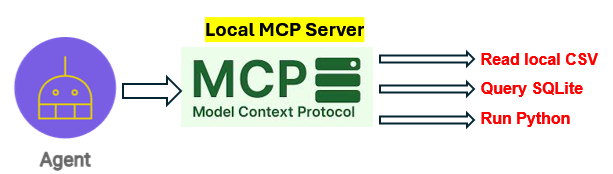

Here is an example of local server:
```python 
from mcp.client.stdio import stdio_client

async with stdio_client(server_params) as (
    read_stream,
    write_stream
)
```
This launches a local MCP process.

A remote MCP server runs somewhere else on the internet. For example, https://docs.devin.ai/work-with-devin/deepwiki-mcp is a remote MCP server.

* **Advantages of Remote MCP**
  * Shared by many users
  * Centralized tools
  * Easier deployment
  * Access cloud resources/APIs
  * No installation needed on client side

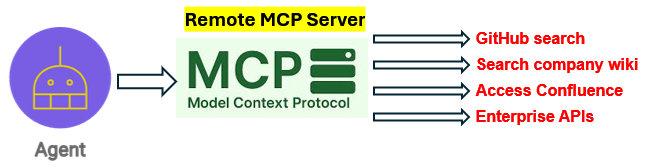

Here is an example of remote MCP server:
```python 
from mcp.client.streamable_http import streamablehttp_client

async with streamablehttp_client(
    "https://mcp.deepwiki.com/mcp"
)
```
This connects to a remote MCP endpoint.

See the examples below for the local and remote MCP server: 

# Local MCP Server 

In this example, we use LangGraph to build an agent and show how it connects to a local MCP server. This is not a universal standard for all platforms—it's simply one implementation approach based on LangGraph’s documented way of integrating with MCP.

In [8]:
#!pip install langchain-mcp-adapters

In [9]:
# Import necessary libraries
from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client
from langchain_mcp_adapters.tools import load_mcp_tools
from langchain.agents import create_agent

# Use nest_asyncio because of using this into jupyter notebook
import nest_asyncio

# Apply nest_asyncio to handle nested event loops
nest_asyncio.apply()

In this setup, we configure a standard input/output (stdio) connection to communicate with an MCP server. The MCP client launches a local server process and communicates with it through `stdin/stdout`. This allows the client to treat the server as a subprocess that exposes tools via the MCP protocol.

The `server_params` object defines how the MCP server process should be started. Specifically, it specifies the Python interpreter to use and the path to the MCP server script. This script runs a local MCP server that exposes tools defined inside it.

Although this example runs locally, the same mechanism can be extended to remote servers or containerized deployments.

```python
from mcp import ClientSession, StdioServerParameters

server_params = StdioServerParameters(
    command=sys.executable,
    args=[os.path.abspath(mcp_path)]
)
```

An important concept here is the separation of responsibilities between the LLM host and the MCP server:

* The host application (the client running LangGraph) is responsible for invoking the LLM.
* The MCP server is responsible for executing the tools.

For example, if a tool relies on a SerpAPI key, the API key only needs to exist in the MCP server environment. The LLM itself does not need direct access to that key. This creates a clean separation between model execution and tool execution.

In other words:

* The LLM handles reasoning and tool selection.
* The MCP server handles the actual execution of external tools and APIs.

These components can even run in completely different environments. In the next lesson, we will demonstrate how MCP servers can run inside Docker containers. As long as the container has the required API keys and dependencies configured, LangGraph can communicate with it seamlessly.


* **Simple Exmaple 1**

Here is a simple MCP server, that is saved as `*.py` file as it is required for MC server.

In [10]:
MCP_SERVER = f'''
from mcp.server.fastmcp import FastMCP
from langchain_community.utilities import SerpAPIWrapper
import os

mcp = FastMCP("Simple MCP Example")

# Register this function as a callable MCP tool.
@mcp.tool()
def multiply(a: float, b: float) -> int:
    """Multiply two float numbers"""
    return a * b

@mcp.tool()
def add(a: float, b: float) -> int:
    """Add two float numbers"""
    return a + b


@mcp.tool()
def google_search(query: str) -> str:
    """Apply Online Realtime Web Search"""
    serpapi = SerpAPIWrapper(serpapi_api_key="{os.getenv("SERP_API_KEY")}")
    return serpapi.run(query)

if __name__ == "__main__":
    mcp.run(transport="stdio")
'''

mcp_path = 'mcp_server_1.py'

with open(mcp_path, 'w') as f:
    f.write(MCP_SERVER)

print("Saved to:", os.path.abspath(mcp_path))

Saved to: D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agents_in_production\mcp_server_1.py


The code below sets up an asynchronous pipeline that connects to a local MCP server (`mcp_server.py`) using a stdio subprocess. It starts the server, creates a session, and initializes communication. Then it loads all tools exposed by the MCP server and prints their metadata. These tools are passed into a LangGraph ReAct agent built on a ChatOpenAI model. Finally, the agent is executed asynchronously with memory support to process the user’s input query. The memory support saves the conversation state so it can remember previous messages in the same thread.

In [11]:
import asyncio
import sys
import os

from langchain_openai import ChatOpenAI
from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client
from rich.markdown import Markdown

llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

# Windows notebook asyncio fix
asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

# MCP server process config
server_params = StdioServerParameters(
    command=sys.executable,
    args=[os.path.abspath(mcp_path)]
)

# async means this function can run cooperatively with other tasks without blocking the program.
async def agent_run_async(m, thread_id="thread_id"):
    # Start MCP stdio connection
    async with stdio_client(server_params, errlog=None) as (read, write):

        # Create MCP session
        async with ClientSession(read, write) as session:

            # Initialize MCP connection
            await session.initialize()

            # Load MCP tools into LangGraph
            mcp_tools = await load_mcp_tools(session)

            # Print discovered tools
            for tool in mcp_tools:
                print(f'Tool Name: {tool.name}')
                print(f'Tool Description: {tool.description}')
                print(f'Tool Arguments Schema: {tool.args_schema}')
                print(f'Tool Response Format: {tool.response_format}')
                print('-' * 40)

            # Create agent with MCP tools
            agent = create_agent(
                llm,
                mcp_tools,
                checkpointer=MemorySaver()
            )

            # Run agent
            return await agent.ainvoke(
                {"messages": m},
                config={"configurable": {"thread_id": thread_id}}
            )

In [12]:
agent_response = await agent_run_async("What is current home price on average for a detached house in Calgary times 12?", thread_id='my test')

Tool Name: multiply
Tool Description: Multiply two float numbers
Tool Arguments Schema: {'properties': {'a': {'title': 'A', 'type': 'number'}, 'b': {'title': 'B', 'type': 'number'}}, 'required': ['a', 'b'], 'title': 'multiplyArguments', 'type': 'object'}
Tool Response Format: content_and_artifact
----------------------------------------
Tool Name: add
Tool Description: Add two float numbers
Tool Arguments Schema: {'properties': {'a': {'title': 'A', 'type': 'number'}, 'b': {'title': 'B', 'type': 'number'}}, 'required': ['a', 'b'], 'title': 'addArguments', 'type': 'object'}
Tool Response Format: content_and_artifact
----------------------------------------
Tool Name: google_search
Tool Description: Apply Online Realtime Web Search
Tool Arguments Schema: {'properties': {'query': {'title': 'Query', 'type': 'string'}}, 'required': ['query'], 'title': 'google_searchArguments', 'type': 'object'}
Tool Response Format: content_and_artifact
----------------------------------------


[06/08/26 21:09:30] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=565200;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=690173;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\
                             "HTTP/1.1 200 OK"                                                                     

[06/08/26 21:09:32] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=650885;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=686798;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\
                             "HTTP/1.1 200 OK"                                                                     

[06/08/26 21:09:33] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=107051;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=124683;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\
                             "HTTP/1.1 200 OK"                                                                     

In [13]:
# Last message
agent_response['messages'][-1]

AIMessage(content='The current average price for a detached house in Calgary is approximately $844,352. Multiplying this by 12 gives $10,132,224.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 639, 'total_tokens': 671, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_81d3e80949', 'id': 'chatcmpl-Doh8IlBUtqvJlrRwYdde4HOXymB3e', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019eaa5b-544e-7311-a469-2876a1f469ab-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 639, 'output_tokens': 32, 'total_tokens': 671, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

This code below is debugging / inspecting an LLM agent response (likely from LangGraph + MCP tool calling). It prints out a structured view of the model’s messages, especially focusing on tool calls made to an MCP server. **Looping over all messages produced by the agent**.

In [14]:
for message in agent_response['messages']:
    print(type(message), message.content, 'Tool ID:' + message.tool_call_id if hasattr(message, 'tool_call_id') else '')
    if message.additional_kwargs.get('tool_calls'):
        for tool_call in message.additional_kwargs.get('tool_calls'):
            print(f'Tool Call: ID({tool_call["id"]}), Name({tool_call["function"]["name"]}), Args({tool_call["function"]["arguments"]})')
    print('----')

<class 'langchain_core.messages.human.HumanMessage'> What is current home price on average for a detached house in Calgary times 12? 
----
<class 'langchain_core.messages.ai.AIMessage'>  
----
<class 'langchain_core.messages.tool.ToolMessage'> [{'type': 'text', 'text': "['Average Prices · Detached homes $844,352, down 0.3% year-over-year and up 1.7% from April. · Semi-detached homes $658,309, down 4.1% year-over-year and down 4.7% ...', 'C$1,150,000. 5 bds; 4 ba; 2,540 sqft. House for sale · C$974,900. 3 bds; 3 ba; 1,652 sqft. House for sale · Loading... · C$839,900. 6 bds; 3 ba; 1,050 sqft. House ...', 'Current mid data shows median detached prices in June was $728,000. It is currently down to $692k. Sales are down 16% Y/Y. https://www.creb ...', 'Detached* Row & TownHouse* Semi- Detached* Average Price 612,804 650,228 665,742 8.64% Average Price 713,801 717,357 670,096 647,817 704,668 8.78% only ...', 'Median home prices by building type · Row/Townhouses: -6.9% · Semi-detached homes:

In [15]:
len(agent_response['messages'])

6

* **Simple Exmaple 2**

Here is another local MCP server. This MCP server exposes a simple local filesystem toolset that lets an agent create and modify files inside a controlled workspace directory (`mcp_workspace`). It provides two tools: `create_file` to create a new file with optional content, and `write_file` to append content to an existing file. The server runs over stdio so it can be connected to by an MCP client or agent process.

In [16]:
MCP_SERVER = '''

from mcp.server.fastmcp import FastMCP
import os

mcp = FastMCP("local-filesystem")

BASE_DIR = os.path.abspath("./mcp_workspace")

os.makedirs(BASE_DIR, exist_ok=True)


@mcp.tool()
# async means this function can run cooperatively with other tasks without blocking the program.
async def create_file(path: str, content: str = ""):
    full_path = os.path.join(BASE_DIR, path)

    os.makedirs(os.path.dirname(full_path), exist_ok=True)

    with open(full_path, "w", encoding="utf-8") as f:
        f.write(content)

    return {"status": "created", "path": full_path}


@mcp.tool()
async def write_file(path: str, content: str):
    full_path = os.path.join(BASE_DIR, path)

    with open(full_path, "a", encoding="utf-8") as f:
        f.write(content)

    return {"status": "written", "path": full_path}

@mcp.tool()
async def create_xy_file(n: int = 100):
    lines = ["x y"]
    for i in range(1, n+1):
        lines.append(f"{i} {n-i+1}")
    return "\\n".join(lines)
    
if __name__ == "__main__":
    mcp.run(transport="stdio")
'''

mcp_path = 'mcp_server_2.py'

with open(mcp_path, 'w') as f:
    f.write(MCP_SERVER)

print("Saved to:", os.path.abspath(mcp_path))


Saved to: D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agents_in_production\mcp_server_2.py


In [17]:
import asyncio
import sys

from langchain_openai import ChatOpenAI
from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client

# Windows notebook asyncio fix
asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

# MCP server process config
server_params = StdioServerParameters(
    command=sys.executable,
    args=[os.path.abspath(mcp_path)]
)

async def agent_run_async(m, thread_id="thread_id"):

    # Start MCP stdio connection
    async with stdio_client(server_params, errlog=None) as (read, write):

        # Create MCP session
        async with ClientSession(read, write) as session:

            # Initialize MCP connection
            await session.initialize()

            # Load MCP tools into LangGraph
            mcp_tools = await load_mcp_tools(session)

            # Print discovered tools
            for tool in mcp_tools:
                print(f'Tool Name: {tool.name}')
                print(f'Tool Description: {tool.description}')
                print(f'Tool Arguments Schema: {tool.args_schema}')
                print(f'Tool Response Format: {tool.response_format}')
                print('-' * 40)

            # Create agent with MCP tools
            agent = create_agent(
                llm,
                mcp_tools,
            #    checkpointer=MemorySaver()
            )

            # Run agent
            return await agent.ainvoke(
                {"messages": m},
                config={"configurable": {"thread_id": thread_id}}
            )


In [18]:
prompt = """Create 10 text file named 'sample_1.txt' to 'sample_10.txt' each with 2 columns: x  y. 
- x column should have 100 rows: starts from 1 to 100 with 1 interval. 
- y column should have 100 rows: starts from 100 to 1 with 1 interval. 

each text file shoule be like this:
x     y    
1    100
.     .    
.     . 
100   1 
"""

agent_response = await agent_run_async(prompt, thread_id='my test')

Tool Name: create_file
Tool Description: 
Tool Arguments Schema: {'properties': {'path': {'title': 'Path', 'type': 'string'}, 'content': {'default': '', 'title': 'Content', 'type': 'string'}}, 'required': ['path'], 'title': 'create_fileArguments', 'type': 'object'}
Tool Response Format: content_and_artifact
----------------------------------------
Tool Name: write_file
Tool Description: 
Tool Arguments Schema: {'properties': {'path': {'title': 'Path', 'type': 'string'}, 'content': {'title': 'Content', 'type': 'string'}}, 'required': ['path', 'content'], 'title': 'write_fileArguments', 'type': 'object'}
Tool Response Format: content_and_artifact
----------------------------------------
Tool Name: create_xy_file
Tool Description: 
Tool Arguments Schema: {'properties': {'n': {'default': 100, 'title': 'N', 'type': 'integer'}}, 'title': 'create_xy_fileArguments', 'type': 'object'}
Tool Response Format: content_and_artifact
----------------------------------------


[06/08/26 21:09:40] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=187276;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=70491;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\
                             "HTTP/1.1 200 OK"                                                                     

[06/08/26 21:10:34] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=26383;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=49045;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\
                             "HTTP/1.1 200 OK"                                                                     

[06/08/26 21:10:35] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=222316;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=643931;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\
                             "HTTP/1.1 200 OK"                                                                     

In [30]:
# Last message
print(agent_response["messages"][-1].content)

Alan Turing's major contributions to computer science can be summarized as follows:

1. Turing Machine: Alan Turing introduced the concept of the Turing machine, an abstract computational model that formalized the notion of algorithm and computation. This foundational concept is central to the theory of computation and computer science.

2. Cryptanalysis during World War II: Turing played a crucial role in breaking the German Enigma code during World War II. His work in cryptanalysis significantly contributed to the Allied victory and laid the groundwork for modern computer science and cryptography.

3. Computing Machinery and Intelligence: Turing explored the idea of artificial intelligence and proposed the Turing test as a criterion for machine intelligence. This test evaluates a machine's ability to exhibit intelligent behavior indistinguishable from that of a human.

4. Early Computer Development: Turing was involved in the design and development of early computers, including the A

# Remote MCP Server

A remote MCP server is a cloud-hosted MCP server that lets **AI agents connect to external tools** and data over the internet using HTTP-based communication, instead of running locally on your computer. It acts like a standardized bridge between LLMs and services such as GitHub, databases, Slack, or cloud platforms. Remote MCP servers simplify integrations because clients can securely access tools through one common protocol rather than building custom APIs for every service.

Here is list of curated list of high quality remote MCP servers: https://mcpservers.org/remote-mcp-servers

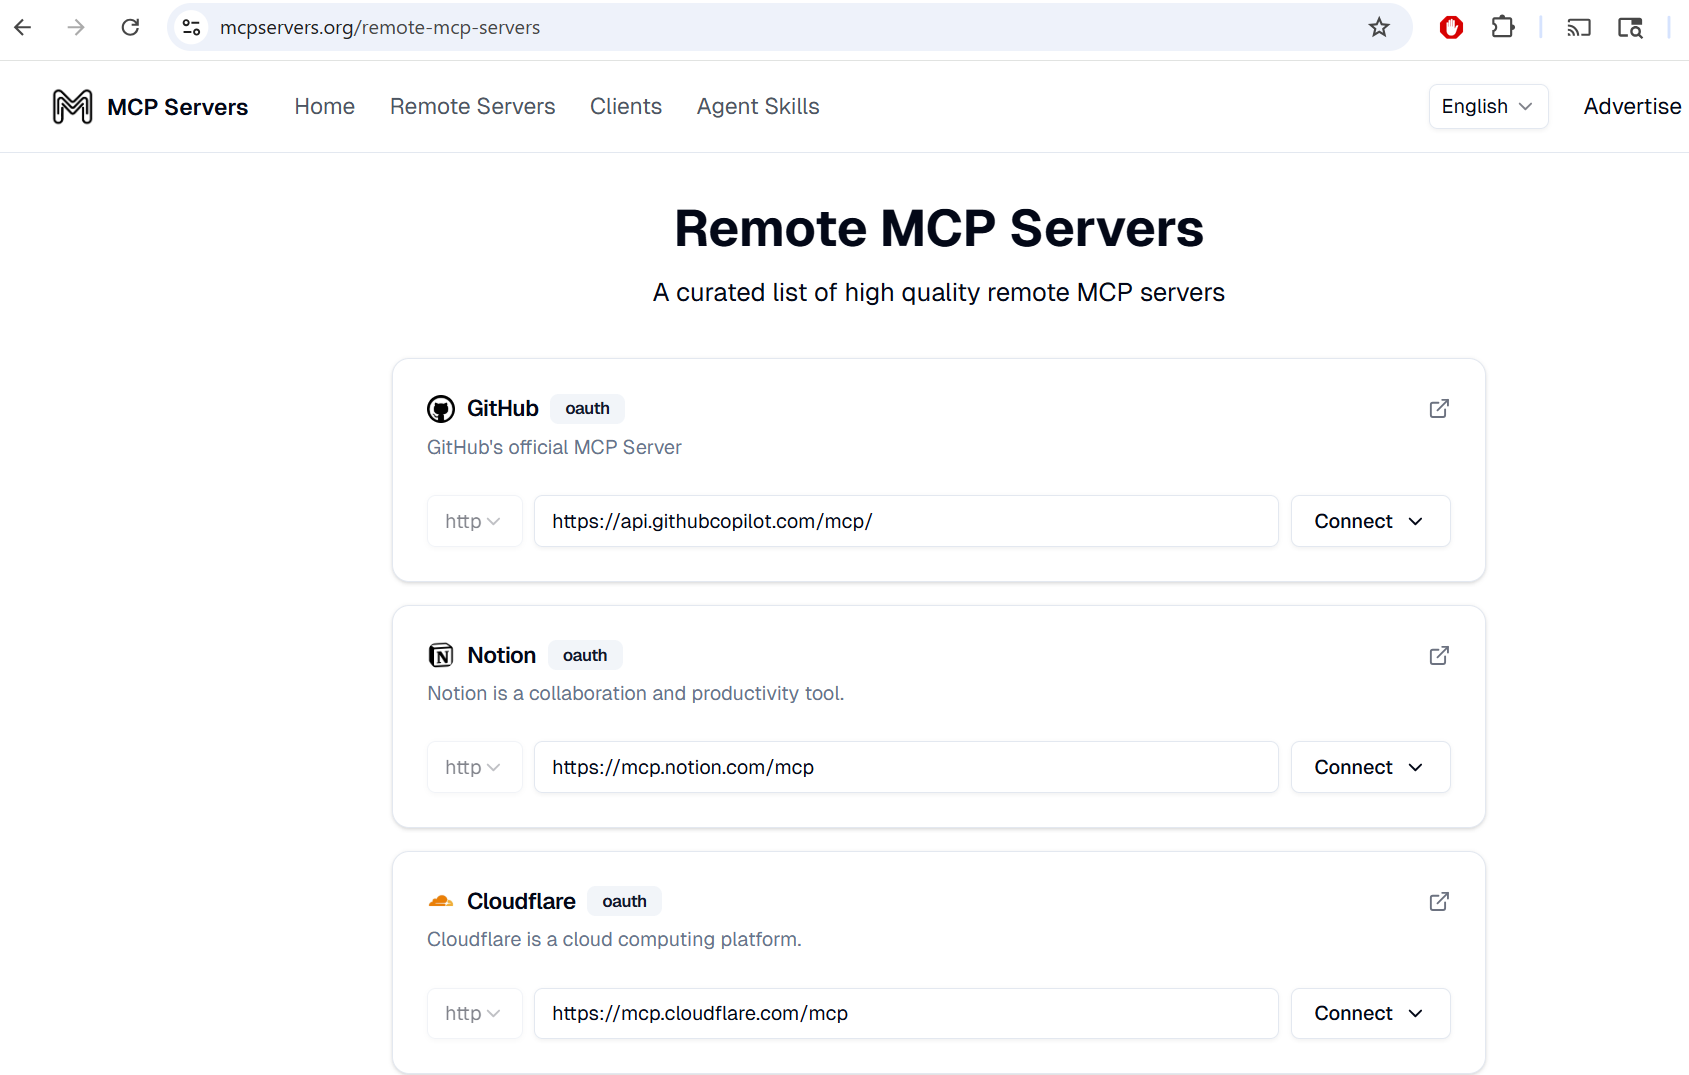

In [158]:
from langchain_core.tools import StructuredTool
# Make MCP connection call only once
from mcp import ClientSession
from mcp.client.streamable_http import streamablehttp_client

from langchain_core.tools import StructuredTool
from langchain.agents import create_agent

from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

mcp_ctx = None
session = None
agent = None

In [159]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

This function initializes an MCP client session to connect to a remote MCP server **DeepWiki MCP Server** https://mcp.deepwiki.com/ and discover available tools on https://deepwiki.com/. It dynamically wraps each discovered MCP tool into a LangChain StructuredTool, then builds an agent (create_agent) that can use those tools with an LLM. Finally, it prints the registered tool metadata (name, schema, etc.) to confirm the agent is ready.

In [160]:
# Startup Function
async def startup():

    global mcp_ctx
    global session
    global agent

    mcp_ctx = streamablehttp_client(
        "https://mcp.deepwiki.com/mcp")

    read_stream, write_stream, _ = await mcp_ctx.__aenter__()

    session_ctx = ClientSession(
        read_stream,
        write_stream
    )

    session = await session_ctx.__aenter__()

    await session.initialize()

    tools_response = await session.list_tools()

    mcp_tools = []

    for t in tools_response.tools:

        tool_name = t.name

        async def mcp_tool(
            arguments: dict,
            tool_name=tool_name
        ):
            result = await session.call_tool(
                tool_name,
                arguments
            )

            return str(result.content)

        wrapped_tool = StructuredTool.from_function(
            func=mcp_tool,
            name=tool_name,
            description=f"MCP tool: {tool_name}"
        )

        mcp_tools.append(wrapped_tool)

    agent = create_agent(
        model=llm,
        tools=mcp_tools,
        checkpointer=memory
    )

    print("MCP Agent Ready")
    
    # Print discovered tools
    for tool in mcp_tools:
        print(f'Tool Name: {tool.name}')
        print(f'Tool Description: {tool.description}')
        print(f'Tool Arguments Schema: {tool.args_schema}')
        print(f'Tool Response Format: {tool.response_format}')
        print('-' * 40)

In [161]:
await startup()

[06/08/26 22:09:58] INFO     HTTP Request: POST https://mcp.deepwiki.com/mcp "HTTP/1.1 200 OK"      ]8;id=405925;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=450172;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\

                    INFO     Negotiated protocol version: 2025-11-25                         ]8;id=747617;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\mcp\client\streamable_http.py\streamable_http.py]8;;\:]8;id=262054;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\mcp\client\streamable_http.py#193\193]8;;\

[06/08/26 22:09:59] INFO     HTTP Request: POST https://mcp.deepwiki.com/mcp "HTTP/1.1 202          ]8;id=83806;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=925552;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\
                             Accepted"                                                                             

                    INFO     HTTP Request: POST https://mcp.deepwiki.com/mcp "HTTP/1.1 200 OK"      ]8;id=893587;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=334076;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\

MCP Agent Ready
Tool Name: read_wiki_structure
Tool Description: MCP tool: read_wiki_structure
Tool Arguments Schema: <class 'langchain_core.utils.pydantic.read_wiki_structure'>
Tool Response Format: content
----------------------------------------
Tool Name: read_wiki_contents
Tool Description: MCP tool: read_wiki_contents
Tool Arguments Schema: <class 'langchain_core.utils.pydantic.read_wiki_contents'>
Tool Response Format: content
----------------------------------------
Tool Name: ask_question
Tool Description: MCP tool: ask_question
Tool Arguments Schema: <class 'langchain_core.utils.pydantic.ask_question'>
Tool Response Format: content
----------------------------------------


As can be seen, the DeepWiki MCP server offers three main tools:

1. **`read_wiki_structure`** - Get a list of documentation topics for a GitHub repository 
2. **`read_wiki_contents`** - View documentation about a GitHub repository 
3. **`ask_question`** - Ask any question about a GitHub repository and get an AI-powered, context-grounded response

In [162]:
async def agent_run_async(message, thread_id="default"):
        # Run agent
        return await agent.ainvoke(
            {"messages": message},
            config={"configurable": {"thread_id": thread_id}}
        )

In [163]:
query = """What topics are covered in the langchain-ai/langgraph?"""
query = """What topics are covered in the microsoft/vscode?"""


In [164]:
agent_response = await agent_run_async(query, thread_id='my test')

[06/08/26 22:10:02] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=453945;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=265694;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\
                             "HTTP/1.1 200 OK"                                                                     

D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\langchain_core\tools\base.py:642: RuntimeWarning: coroutine 'startup.<locals>.mcp_tool' was never awaited
  return self.run(tool_input, **kwargs)


[06/08/26 22:10:03] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=68865;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=766327;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\
                             "HTTP/1.1 200 OK"                                                                     

D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\langchain_core\tools\base.py:642: RuntimeWarning: coroutine 'startup.<locals>.mcp_tool' was never awaited
  return self.run(tool_input, **kwargs)


[06/08/26 22:10:04] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=353617;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=122639;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\
                             "HTTP/1.1 200 OK"                                                                     

...

[06/08/26 22:10:12] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=116827;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=166147;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\
                             "HTTP/1.1 200 OK"                                                                     

D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\langchain_core\tools\base.py:642: RuntimeWarning: coroutine 'startup.<locals>.mcp_tool' was never awaited
  return self.run(tool_input, **kwargs)


[06/08/26 22:10:13] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=33073;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=638271;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\
                             "HTTP/1.1 200 OK"                                                                     

D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\langchain_core\tools\base.py:642: RuntimeWarning: coroutine 'startup.<locals>.mcp_tool' was never awaited
  return self.run(tool_input, **kwargs)


[06/08/26 22:10:15] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=337472;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=750852;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1786\1786]8;;\
                             "HTTP/1.1 200 OK"                                                                     

In [165]:
# Last message
print(agent_response["messages"][-1].content)

The topics covered in the microsoft/vscode page include the following sections:

1. Overview
2. Features
3. History
4. Development
5. Reception
6. See also
7. References
8. External links

If you want, I can provide more detailed information about each section.


In [166]:
used_tools = set()

for msg in agent_response["messages"]:
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        for tc in msg.tool_calls:
            used_tools.add(tc["name"])
            
if used_tools:
    for tool in sorted(used_tools):
        print(f"- 🛠️ {tool}")

- 🛠️ read_wiki_contents
- 🛠️ read_wiki_structure


Now ask the same question from LLM without using MCP server

In [167]:
agent_no_tools = create_agent(llm,)

from langchain_core.messages import HumanMessage

response = agent_no_tools.invoke({
    "messages": [HumanMessage(content=query)]
})

print(response["messages"][-1].content)

[06/08/26 22:20:25] INFO     HTTP Request: POST https://api.openai.com/v1/chat/completions          ]8;id=553217;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py\_client.py]8;;\:]8;id=91052;file://D:\Learning\MyWebsite\FinalGithub\ToPublihsed\projects\Agentic_Workflow\agentic_workflow\Lib\site-packages\httpx\_client.py#1038\1038]8;;\
                             "HTTP/1.1 200 OK"                                                                     

The **microsoft/vscode** repository on GitHub primarily covers topics related to the development of **Visual Studio Code**, which is a popular open-source code editor. The main topics include:

1. **Source Code Editor**  
   - Core editor features such as syntax highlighting, code folding, bracket matching, and multi-cursor editing.

2. **Extensions and APIs**  
   - Support for extensions, extension API design, and extension marketplace integration.

3. **Language Support**  
   - Built-in support and integration for various programming languages, including IntelliSense, debugging, and language servers.

4. **User Interface and Experience**  
   - UI components, theming, layout, and customization options.

5. **Debugging**  
   - Debug adapter protocol implementation and debugging features for multiple languages.

6. **Version Control Integration**  
   - Git and other SCM integrations.

7. **Performance and Optimization**  
   - Improvements related to startup time, responsiveness, a

# Summary

From the LLM’s perspective, **nothing has fundamentally changed**. It is still operating as a standard tool-calling model, interacting through human messages, AI messages, and tool messages exactly as before. The agent itself does not care whether an MCP server is running in the background. To the LLM, tools simply appear in the prompt, and it decides which tool to call.

The only real difference is **where the tool execution happens**. Instead of running locally or inside the application, the request is routed through an **MCP server**. For example, the LLM may decide to call a tool, LangGraph or LangChain converts that request into an MCP call, the **MCP server executes the tool**, and the result is returned back to the agent as a tool message. **From the LLM’s perspective, the workflow remains unchanged.**

Because of this, whether or not we use an MCP server is primarily a **development and architecture choice**. It does not change the LLM’s tool-calling capabilities, and it is irrelevant when evaluating whether the model itself can effectively use tools.

What MCP changes is the infrastructure layer. MCP provides a **standardized way to expose, share, and manage tools, prompts, and resources** across systems and organizations. While it still has limitations and evolving standards, it is becoming an important foundation for building interoperable AI agents and enabling collaboration between different applications and ecosystems.

## Risk Using MCP

MCP is a powerful idea, but it is not without risks. For example, some MCP servers could potentially be misused to access sensitive or private information. However, this is not a flaw in MCP itself, nor is it a fault of platforms like GitHub. Rather, it reflects a broader challenge in how LLMs are granted access to external tools and how those tools are composed and chained together.

In many cases, security issues arise when tool access is not carefully scoped, and when combinations of tools can be orchestrated in unintended or malicious ways. For instance, there have been scenarios where an LLM, through a GitHub MCP integration, was able to interact with repositories it should not have had access to.

The key point is that everything in this stack has potential vulnerabilities—LLMs, MCP servers, and tool integrations. MCP itself is simply a standard for structuring and unifying tool calling in LLM systems. It does not inherently introduce the problem; rather, it defines a mechanism that can be misused if the underlying access controls and model behavior are not properly constrained.

In this sense, **the issue is less about MCP as a protocol and more about how LLMs interpret and execute tool usage in potentially adversarial contexts.**